## Background

**Dataset:** `sklearn.datasets.make_moons`

`make_moons` is a synthetic dataset from `sklearn` that generates a **two-class, two-dimensional** dataset shaped like two half-circles. Because the boundary between classes is curved, **no linear decision boundary can cleanly separate them**. In this lab, we will compare the three different SVM Kernels to see which performs best.



## Step 1: Setup: Load Libraries and Generate Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, roc_auc_score,
                              RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay)

Class distribution:
1    1000
0    1000
Name: count, dtype: int64


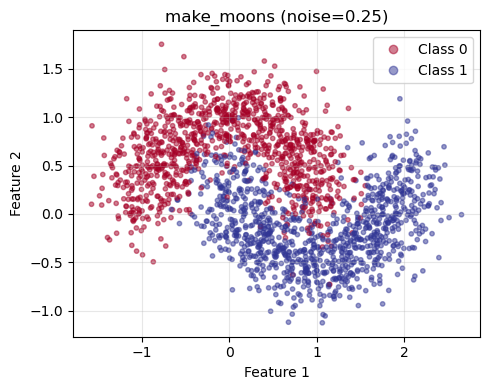

In [2]:

# The `noise` parameter adds Gaussian noise to the coordinates
# Higher noise blurs the boundary and makes the problem harder
# Too little noise makes it trivial

X, y = make_moons(n_samples=2000, noise=0.25, random_state=42)

print(f"Class distribution:\n{pd.Series(y).value_counts()}")

fig, ax = plt.subplots(figsize=(5, 4))
scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', s=10, alpha=0.5)
handles, _ = scatter.legend_elements()
ax.legend(handles, ['Class 0', 'Class 1'])
ax.set_title('make_moons (noise=0.25)')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The dataset has two features and two balanced classes:

| Feature | Description |
|---------|-------------|
| `X[:, 0]` | x-coordinate (with noise) |
| `X[:, 1]` | y-coordinate (with noise) |



## Step 2: Preprocessing

SVMs are scale-variant, so we always apply `StandardScaler` before fitting. Split your data using `train_test_split` with a test_size of 0.3,  `random_state = 42`, and `stratify = y`. 

In [3]:
# split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, stratify = y, random_state = 42)

# initiate scaler
scaler = StandardScaler().fit(X_train)

# scale X train and X test
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

---

## Background: Support Vector Classifier

The **support vector classifier** (SVC) fits a linear decision boundary by maximizing the margin between classes while allowing some observations to violate it. The penalty hyperparameter `C` controls how harshly violations are penalized:

- **Large C**( 100 to 1000): violations penalized heavily → narrow margin, fewer support vectors, tighter fit to training data
- **Small C** ( 0.0001 to 1): violations tolerated → wide margin, more support vectors, smoother boundary

## Step 3: Tune a Linear SVM with GridSearchCV

---

Use `GridSearchCV` with 5-fold cross-validation, search over the following values of `C` to find the best linear kernel configuration. Report the best parameters, CV accuracy, and test accuracy.

`C`: .001, .01, 0.1, 1, 10, 100



In [4]:
# save parameters
parameters = {'C':[0.001, 0.01, 0.1, 1, 10, 100]}

# perform grid search
grid_linear = GridSearchCV( # runs cv for all combinations of these hyperparameters
    SVC(kernel = 'linear', random_state = 42),
    param_grid = parameters,
    cv = 5,
    scoring = "accuracy",
    n_jobs = -1 # specifies parallel processing
)

# fit to data
grid_linear.fit(X_train_scaled, y_train)

# save results
best_linear = grid_linear.best_estimator_
test_acc_linear = accuracy_score(y_test, best_linear.predict(X_test_scaled))


# report results
print(f"Best params: {grid_linear.best_params_}")
print(f"CV Accuracy: {grid_linear.best_score_:.3f}")
print(f"Test Accuracy: {test_acc_linear:.3f}")

Best params: {'C': 1}
CV Accuracy: 0.860
Test Accuracy: 0.880


##### Look at the accuracy each value of C yielded in `grid_linear`. Hint: You can access the cross validation results using `.cv_results`, then select only the `param_C` and `mean_test_score` column. Convert these results into a DataFrame for easier interpretation!

In [5]:
# convert results into df and select specific columns
linear_res = pd.DataFrame(grid_linear.cv_results_)
linear_res[['param_C', 'mean_test_score']]

,param_C,mean_test_score
0,0.001,0.847143
1,0.01,0.853571
2,0.1,0.856429
3,1,0.860000
4,10,0.860000
5,100,0.860000


> **Q1: What `C` value did cross-validation select? Given that the moons boundary is curved, did you expect the linear kernel to achieve strong accuracy regardless of `C`? At what value of C does the accuracy stop improving?**

Cross-validation selected a C value of 1. Given that the moons boundary is curved, I did **not** expect the linear kernel to achieve strong accuracy regardless of `C`. At C = 1 the accuracy stops improving and remains 0.86.

---

## Background: RBF Kernel

When the true decision boundary is non-linear, we replace the inner product in the SVC formulation with a **kernel function** that implicitly maps observations into a higher-dimensional space. The **radial basis function (RBF)** kernel measures similarity by distance:

$$K(x_i, x_j) = \exp\!\left(-\gamma \|x_i - x_j\|^2\right)$$

The hyperparameter $\gamma$ controls how quickly influence decays with distance:

- **Large $\gamma$** → complex, local boundary (high variance risk)
- **Small $\gamma$** → smooth, global boundary (high bias risk)

Both `C` and `gamma` need to be tuned jointly via cross-validation.

## Step 4: Tune an RBF SVM with GridSearchCV

Using `GridSearchCV` with 5-fold cross-validation and `random_state = 42`,search over the following values of `C`,and `gamma` to find the best polynomial kernel configuration. Report the best parameters, CV accuracy, and test accuracy.

`C`: 0.1, 1, 10, 100
`gamma`: `scale`, 0.001, 0.01, 0.1, 1, 10

In [6]:
# save parameters
parameters = {'C':[0.01, 0.1, 1, 10, 100],
             'gamma':['scale', 0.001, 0.01, 0.1, 1, 10]}

# perform grid search
grid_rbf = GridSearchCV( # runs cv for all combinations of these hyperparameters
    SVC(kernel = 'rbf',
        random_state = 42),
    parameters,
    cv = 5,
    scoring = "accuracy",
    n_jobs = -1 # specifies parallel processing
)

# fit to data
grid_rbf.fit(X_train_scaled, y_train)

# save results
rbf_acc  = accuracy_score(y_test, grid_rbf.predict(X_test_scaled))
best_rbf = grid_rbf.best_estimator_

# report results
print(f"Best parameter:  {grid_rbf.best_params_}")
print(f"CV accuracy: {grid_rbf.best_score_:.3f}")
print(f"Test accuracy: {rbf_acc:.3f}")

Best parameter:  {'C': 1, 'gamma': 1}
CV accuracy: 0.948
Test accuracy: 0.938


> **Q2: How much does the RBF kernel improve over the linear SVM? Do the best `C` and `gamma` values suggest a smooth or tightly-fitted boundary?**

The test accuracy improves by 0.06 from the linear to the RBF kernel. 

The best `C` value is 1, which is relatively low and creates a softer margin, allowing some misclassification. The best `gamma` value of 1 is considered moderate and balances bias and variance. This way, it guards against both severe under and overfitting.

---

## Background: Polynomial Kernel

The **polynomial kernel** of degree $d$ is:

$$K(x_i, x_j) = ( \gamma \langle x_i, x_j \rangle + r)^d$$


Higher degree allows the boundary to curve more, capturing complex feature interactions, but also increases the risk of overfitting. The `coef0` term (r in the formula above) weights the influence of lower-degree polynomial terms.

## Step 5: Tune a Polynomial SVM with GridSearchCV

Using `GridSearchCV` with 5-fold cross-validation and `random_state = 42`, search over the following values of `C`, `degree`, and `coef0` to find the best polynomial kernel configuration. Report the best parameters, CV accuracy, and test accuracy.

`C`: 0.1, 1, 10, 100
`gamma`: 'scale', 0.001, 0.01, 0.1, 1
`degree`: 2, 3, 4
`coef0`: 0.0, 1.0

In [7]:
# save parameters
parameters = {'C':[0.01, 0.1, 1, 10, 100],
             'gamma':['scale', 0.001, 0.01, 0.1, 1],
             'degree':[2, 3, 4],
             'coef0':[0.0, 1.0]}

# perform grid search
grid_poly = GridSearchCV( # runs cv for all combinations of these hyperparameters
    SVC(kernel = 'poly', random_state = 42),
    parameters,
    cv = 5,
    scoring = "accuracy",
    n_jobs = -1 # specifies parallel processing
)

# fit to data
grid_poly.fit(X_train_scaled, y_train)

# save results
poly_acc  = accuracy_score(y_test, grid_poly.predict(X_test_scaled))
best_poly = grid_poly.best_estimator_

# report results
print(f"Best parameter:  {grid_poly.best_params_}")
print(f"CV accuracy: {grid_poly.best_score_:.3f}")
print(f"Test accuracy:    {poly_acc:.3f}")

Best parameter:  {'C': 1, 'coef0': 1.0, 'degree': 3, 'gamma': 1}
CV accuracy: 0.945
Test accuracy:    0.940


> **Q3: Which degree polynomial did GridSearchCV select? How does the polynomial kernel's accuracy compare to the RBF kernel for this crescent-shaped data? Does a higher degree always help, and why or why not?**

GridSearchCV selected a grid polynomial of 3. The test accuracy from the RBF kernel to the polynomial kernel improved by 0.002.

A higher degree does not always help because it can lead to overfitting to the training data and subsequently a lower test accuracy.

---

## Step 6: Streamlining the Hyperparameter Search

Rather than selecting a kernel first and tuning it separately, we can treat the kernel type itself as a hyperparameter. `GridSearchCV` accepts a list of parameter grids, letting each kernel specify its own relevant parameters in a single joint search. Create a joint search where each search grid we used above is included as a dictionary item, with its specified kernel included. `param_grid_all` should be a list of three dictionaries. Then, Using `GridSearchCV` with 5-fold cross-validation and `random_state = 42`, search over the parameter grid you created to find the best configuration. Report the best parameters, CV accuracy, and test accuracy.

In [8]:
# create grids of parameters for all kernels
param_grid_all = [
    
    {'kernel':['linear'],
     'C': [.01, 0.1, 1, 10, 100],
    },
    
    { 'kernel':['rbf'],
      'gamma': ['scale', 0.001, 0.01, 0.1, 1, 10], # scale changes to your data --> (1/# of features) * var of X
      'C': [0.1, 1, 10, 100]
    }, 
    
    {'kernel':['poly'],
     'C':[0.1, 1, 10, 100],
     'gamma': ['scale', .001, .01, .1, 1],
     'degree': [2, 3, 4],
     'coef0': [0, 1]
    }  
    
]

# search across all kernels
grid_overall = GridSearchCV(
    SVC(random_state=42),
    param_grid = param_grid_all, 
    cv = 5,
    scoring = "accuracy",
    n_jobs = -1)

# fit
grid_overall.fit(X_train_scaled, y_train)

# find the best estimator and accuracy
best_overall = grid_overall.best_estimator_
test_acc_overall = accuracy_score(y_test, best_overall.predict(X_test_scaled))

# print results
print(f"Best params: {grid_overall.best_params_}")
print(f"CV Accuracy: {grid_overall.best_score_:.3f}")
print(f"Test Accuracy: {test_acc_overall:.3f}")

Best params: {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
CV Accuracy: 0.948
Test Accuracy: 0.938


> **Q4: Which kernel did the overall search select as best? Is this consistent with the cross validation accuracy from the individual kernel results? Given the curved, crescent-shaped structure of the moons data, does the winning kernel make intuitive sense?**

The overall search selected RBF as the best kernel. This is consistent with the cross validation accuracy across the individual kernel results, as RBF had the highest CV accuracy of 0.948.

The winning kernel does make intuitive sense because RBF works well with non-linear data and when the shape of the data is unknown. It is able to pick up on the crescent pattern of our dataframe better than the other model types.

---


## Step 7: Tune a Random Forest with GridSearchCV

Using `GridSearchCV` with 5-fold cross-validation and `random_state = 42`, search over the following values of `n_estimators`, `max_depth`, and `min_samples_leaf` to find the best random forest configuration. Report the best parameters, CV accuracy, and test accuracy.

`n_estimators`: 100, 200
`max_depth` : None, 5, 10
`min_samples_leaf`: 1, 5, 10

In [9]:
# create parameter grid for random forest
param_grid_rf = {
    'n_estimators':[100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_leaf':[1, 5, 10]
}

# cross validation with rf
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state = 42),
    param_grid = param_grid_rf,
    cv = 5,
    scoring = 'accuracy',
    n_jobs = -1)

# fit model
grid_rf.fit(X_train_scaled, y_train)

# find the best estimator and accruacy
best_rf = grid_rf.best_estimator_
test_acc_rf = accuracy_score(y_test, best_rf.predict(X_test_scaled))

# print results
print(f"Best params: {grid_rf.best_params_}")
print(f"CV Accuracy: {grid_rf.best_score_:.3f}")
print(f"Test Accuracy: {test_acc_rf:.3f}")

Best params: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 100}
CV Accuracy: 0.946
Test Accuracy: 0.938


> **Q5:  How does the Random Forest test accuracy compare to the best SVM kernel?**

The test accuracy of the best SVM kernel, or RBF, was 0.938. The test accuracy of the random forest is the exactly the same at 0.938.

---

## Step 8: Visualize Decision Boundaries

Because `make_moons` has only two features, we can plot the full decision region for all four models. This is where the differences between kernels and the tree-based approach become visually obvious. Create four visualizations of the decision boundaries for each model above. Use  `DecisionBoundaryDisplay.from_estimator()` to create the visualizations. Add a title specifying the model/kernel used to each plot. 

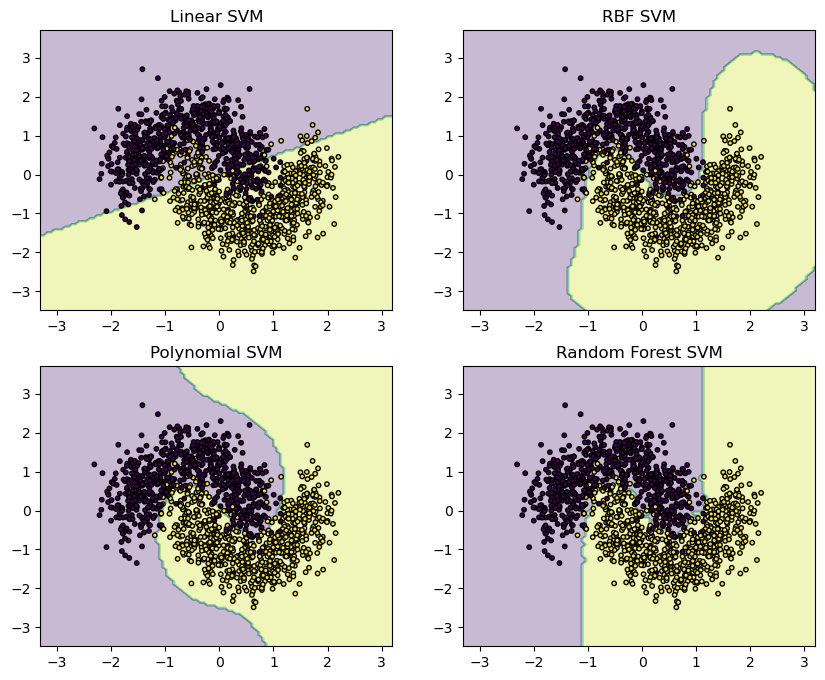

In [10]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

# linear boundaries
#fig, ax = plt.subplots(figsize = (5, 4))
DecisionBoundaryDisplay.from_estimator(best_linear, X_train_scaled, ax = axes[0,0], 
                                       response_method = "predict", # predict boundaries
                                       alpha = 0.3)

axes[0,0].scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c = y_train, s = 10, edgecolors = 'k')
axes[0,0].set_title("Linear SVM")


# rbf boundaries
DecisionBoundaryDisplay.from_estimator(best_rbf, X_train_scaled, ax = axes[0,1], 
                                       response_method = "predict", # predict boundaries
                                       alpha = 0.3)

axes[0,1].scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c = y_train, s = 10, edgecolors = 'k')
axes[0,1].set_title("RBF SVM")


# poly boundaries
DecisionBoundaryDisplay.from_estimator(best_poly, X_train_scaled, ax = axes[1,0], 
                                       response_method = "predict", # predict boundaries
                                       alpha = 0.3)

axes[1,0].scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c = y_train, s = 10, edgecolors = 'k')
axes[1,0].set_title("Polynomial SVM")



# random forest boundaries
DecisionBoundaryDisplay.from_estimator(best_rf, X_train_scaled, ax = axes[1,1], 
                                       response_method = "predict", # predict boundaries
                                       alpha = 0.3)

axes[1,1].scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c = y_train, s = 10, edgecolors = 'k')
axes[1,1].set_title("Random Forest SVM")
plt.show()

> **Q6: How does the linear kernel's decision boundary compare visually to the RBF, polynomial, and Random Forest boundaries? How does the Random Forest boundary differ from the SVM boundaries?**

The linear kernel's decision boundary is linear whereas the others' curve along the shape of the data. The Random Forest boundar differs from Polynomial SVM and RBF SVM because it follows the curve of the data only where the purple and yellow data overlap (in the middle), and makes no assumptions about the boundary's shape after that (visually, this appears as vertical lines at x = ~ -1 and x = ~ 1).

Polynomial SVM and RBF SVM decision boundaries follow the curves of the data more closely. However, this also produces a small purple boundary in the lower left corner of the RBF SVM, which doesn't really seem accurate to the data's distribution.

---

## Step 9: Model Comparison


### Confusion Matrices 

Accuracy alone can hide where models differ in their error patterns. Confusion matrices break down false positives and false negatives. 

##### Create a confusion matrix for each of the four models above. 

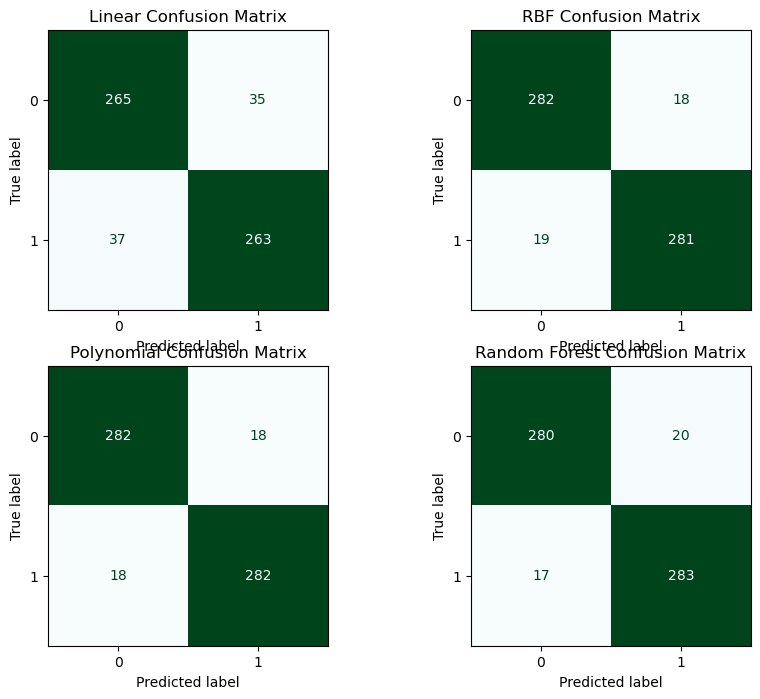

In [11]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

## LINEAR
# Calculate confusiong matrix using test and predicted data
cm_linear = confusion_matrix(y_test, grid_linear.predict(X_test_scaled))

# Save cm display with labels
disp = ConfusionMatrixDisplay(cm_linear,
                       display_labels = ['0', '1'])

# Plot
disp.plot(ax = axes[0,0], colorbar = False, cmap = 'BuGn')
axes[0,0].set_title("Linear Confusion Matrix")

## RBF
# Calculate confusion matrix using test and predicted data
cm_rbf = confusion_matrix(y_test, grid_rbf.predict(X_test_scaled))

# Save cm display with labels
disp = ConfusionMatrixDisplay(cm_rbf,
                       display_labels = ['0', '1'])

# Plot
disp.plot(ax = axes[0,1], colorbar = False, cmap = 'BuGn')
axes[0,1].set_title("RBF Confusion Matrix")

## POLYNOMIAL
# Calculate confusion matrix using test and predicted data
cm_poly = confusion_matrix(y_test, grid_poly.predict(X_test_scaled))

# Save cm display with labels
disp = ConfusionMatrixDisplay(cm_poly,
                       display_labels = ['0', '1'])

# Plot
disp.plot(ax = axes[1,0], colorbar = False, cmap = 'BuGn')
axes[1, 0].set_title("Polynomial Confusion Matrix")

## RANDOM FOREST
# Calculate confusion matrix using test and predicted data
cm_rf = confusion_matrix(y_test, grid_rf.predict(X_test_scaled))

# Save cm display with labels
disp = ConfusionMatrixDisplay(cm_rf,
                       display_labels = ['0', '1'])

# Plot
disp.plot(ax = axes[1,1], colorbar = False, cmap = 'BuGn')
axes[1,1].set_title("Random Forest Confusion Matrix")

plt.show()

>**Q7:Comment on the results of the confusion matrices. Did all four models have similar misclassifications?**

Yes, all 4 models had similar misclassifications, where in each model the number of false negatives and false positives was relatively equal. 

The polynomial kernel had the lowest total number of falsely classified observations (36). The linear kernel had the greatest number of misclassified observations – 35 more than both the RBF and random forest, which each had 37.

### ROC Curves

The **ROC (Receiver Operating Characteristic)** curve plots the true positive rate against the false positive rate as the classification threshold varies. A random classifier follows the diagonal (AUC = 0.50); a perfect classifier has AUC = 1.0.

**AUC (Area Under the Curve)** summarizes the entire ROC curve in a single number that makes it easy to compare different models.

**How ROC works for SVMs specifically:**
Unlike logistic regression, a standard SVC does not output class probabilities. Instead, it computes a decision function — the signed distance of each observation from the decision boundary. Points far on the positive side get large positive scores; points far on the negative side get large negative scores. `RocCurveDisplay.from_estimator` uses this decision function to build the ROC curve.

This means the ROC curve reflects how well each kernel's decision function ranks observations, independent of where the hard boundary is drawn.

##### Plot the ROC Curves for each of the four models on the same plot. Add a line indicating a random classifier (ACU = 0.5) and a legend. 


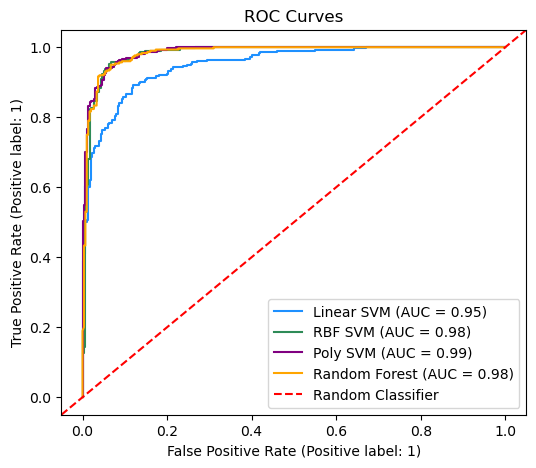

In [12]:
fig, ax = plt.subplots(figsize = (6,5))

# plot ROC curves for each of the 4 models
RocCurveDisplay.from_estimator(best_linear, X_test_scaled, y_test, name = "Linear SVM", ax = ax, color = "DodgerBlue")
RocCurveDisplay.from_estimator(best_rbf, X_test_scaled, y_test, name = "RBF SVM", ax = ax, color = "seagreen")
RocCurveDisplay.from_estimator(best_poly, X_test_scaled, y_test, name = "Poly SVM", ax = ax, color = "purple")
RocCurveDisplay.from_estimator(best_rf, X_test_scaled, y_test, name = "Random Forest", ax = ax, color = "orange")

# add line at random classifier
ax.axline((0, 0), slope=1, color='red', label = "Random Classifier", linestyle='--')

plt.legend()
ax.set_title("ROC Curves")

plt.show()

> **Q8: Do the AUC values align with what you observed in the confusion matrices and accuracy scores? How does the Random Forest compare to the SVM kernels across all three metrics? Considering accuracy, AUC, and the decision boundary shape, which model would you choose for this dataset and why?**

We can see that the linear kernel performs the worst out of all four models because it is the closest to the random classier (and has the smallest AUC). This aligns with what was observed in the confusion matrices and accuracy scores, as it had the largest number of misclassified observations and the lowest accuracy.

The Random Forest model had the same accuracy score as the RBF SVM, which was only a 0.002 lower accuracy than the polynomial SVM. The same pattern is true for the confusion matrices. Comparing ROC curves, it is difficult to distinguish a significant mattern: RBF SVM, Poly SVM, and the random forest model all overlap each other significantly, with RBF and random forest having the same AUC (0.98) and Poly SVM having an AUC of 0.99.

If I were to choose a model based on accuracy, AUC, and the decision boundary shape, I would choose the Polynomial SVM model. It consistently had the highest test accuracy, lowest number of misclassifications, and the largest AUC. I also like how its decision boundary follows the outer curve of the two data clouds. Poly SVM is the most appropriate model for this dataset, despite RBF SVM winning out during the CV hyperparameter search (Step 6).

>**Q9: In terms of overall perforamnce, why does the linear kernel not perform as well as the RBF kernel, Polynomial Kernel, or Random Forest. What is a difference between these latter three models and the former that impacts the shape of the decision boundary and overall accuracy.**

The linear kernel is the only parametric model out of the 4. This means the linear kernel assumes a decision boundary shape before even seeing the data (in this case, linear) and is less able to adapt to its actual distribution. This is particularly detrimental in cases where distributions are curved/non-linear, such as this one. This severely harms the linear kernel's overall accuracy relative to the other three non-parametric models, which are able to adopt decision boundary shape to the curved/non-linear nature of the data. 